In [1]:
import h5py, scipy.io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

In [2]:
# Sessions and probes used by the author's analysis code, read off
# code/HasnainBirnbaum_NatNeuro2024_Code/DataLoadingScripts/Recording and video/load<ANM>_ALMVideo.m.
# Sessions the authors commented out there are left out here, as are JEB4 and JEB5,
# whose recordings are not in data/. A few sessions were recorded with two probes.
SESSIONS = {
    # fixed delay task (data/Ephys_Behavior)
    'EKH1_2021-08-07': [2],
    'EKH3_2021-08-11': [2],
    'JEB6_2021-04-18': [2],
    'JEB7_2021-04-29': [1],
    'JEB7_2021-04-30': [1],
    'JEB13_2022-09-13': [2],
    'JEB13_2022-09-14': [2],
    'JEB13_2022-09-21': [1],
    'JEB13_2022-09-24': [1],
    'JEB13_2022-09-25': [1],
    'JEB14_2022-08-22': [1],
    'JEB14_2022-08-23': [1],
    'JEB14_2022-08-24': [1],
    'JEB14_2022-08-25': [1],
    'JEB15_2022-07-26': [1, 2],
    'JEB15_2022-07-27': [1, 2],
    'JEB15_2022-07-28': [1, 2],
    'JEB15_2022-07-29': [2],
    'JEB19_2023-04-18': [1],
    'JEB19_2023-04-19': [1],
    'JEB19_2023-04-20': [1],
    'JEB19_2023-04-21': [1],
    'JGR2_2021-11-16': [1],
    'JGR2_2021-11-17': [1],
    'JGR3_2021-11-18': [1],

    # randomized delay task (data/RandomizedDelay_Ephys_Behavior)
    'JEB11_2022-05-10': [1],
    'JEB11_2022-05-11': [1],
    'JEB12_2022-05-12': [1],
    'JEB12_2022-05-13': [1],
    'JEB23_2023-10-10': [1],
    'JEB23_2023-10-11': [1],
    'JEB23_2023-10-12': [1],
    'JEB23_2023-10-13': [1],
    'JEB23_2023-10-18': [1],
    'JEB23_2023-10-19': [1],
    'JEB23_2023-10-21': [1],
    'JEB24_2023-10-23': [1],
    'JEB24_2023-10-24': [1],
    'JEB24_2023-10-25': [1],
    'JEB24_2023-10-26': [1],
    'JEB24_2023-10-27': [1],
    'JEB24_2023-10-31': [1],
    'JEB24_2023-11-02': [1],
    'JEB24_2023-11-03': [1],
}

print(len(SESSIONS), 'sessions,', len({s.split('_')[0] for s in SESSIONS}), 'animals')

44 sessions, 14 animals


### Load the Behavioral Data

In [3]:
DATA = Path('data')
EPHYS = ['Ephys_Behavior', 'RandomizedDelay_Ephys_Behavior']

def _h5(f, node):
    """Recursively read an h5py node from a MATLAB v7.3 file."""
    if isinstance(node, h5py.Group):                        # struct
        return {k: _h5(f, node[k]) for k in node}
    if node.attrs.get('MATLAB_class', b'').decode() == 'char':
        return ''.join(chr(c) for c in np.asarray(node[()]).ravel())
    if node.dtype == object:                                # cell array / struct-array field
        return [_h5(f, f[r]) for r in np.asarray(node[()]).ravel()]
    return np.asarray(node[()]).squeeze()

def load_mat(path):
    """Load a data_structure .mat as nested dicts (files are either v7.3 HDF5 or v5)."""
    try:
        with h5py.File(path, 'r') as f:
            return _h5(f, f['obj'])
    except OSError:
        return scipy.io.loadmat(path, simplify_cells=True)['obj']

def session_path(name):
    """Data structure file for a session named like 'JEB19_2023-04-19'."""
    for folder in EPHYS:
        path = DATA / folder / f'data_structure_{name}.mat'
        if path.exists():
            return path
    raise FileNotFoundError(name)

sessions = {name: session_path(name) for name in SESSIONS}
print(len(sessions), 'ephys sessions')

44 ephys sessions


In [4]:
# one session to look around in
obj = load_mat(sessions['JEB19_2023-04-19'])

# behavioral data is in the 'bp' field of the data structure
bp = obj['bp']

print('obj      :', sorted(obj.keys()))
print('bp       :', sorted(bp.keys()))
print('bp.ev    :', sorted(bp['ev'].keys()))
print('Ntrials  :', bp['Ntrials'])
print('probes   :', len(obj['clu']), ' video views:', len(obj['traj']))

obj      : ['bp', 'clu', 'ex', 'me', 'meta', 'pth', 'sglx', 'traj', 'trials']
bp       : ['L', 'Ntrials', 'R', 'autolearn', 'autowater', 'autowaterBlock', 'bitRand', 'early', 'ev', 'hit', 'miss', 'no', 'protocol', 'stim']
bp.ev    : ['bitStart', 'delay', 'goCue', 'lickL', 'lickR', 'reward', 'sample']
Ntrials  : 230.0
probes   : 1  video views: 2


In [5]:
# behavior: one row per trial
trials = pd.DataFrame({
    'sample':    bp['ev']['sample'],
    'delay':     bp['ev']['delay'],
    'goCue':     bp['ev']['goCue'],
    'reward':    bp['ev']['reward'],
    'R':         bp['R'],
    'L':         bp['L'],
    'hit':       bp['hit'],
    'miss':      bp['miss'],
    'no':        bp['no'],
    'early':     bp['early'],
    'autowater': bp['autowater'],
    'stim':      bp['stim']['enable'],
})
print(trials.shape)
display(trials.head(10))
print(trials.mean(numeric_only=True))

(230, 12)


,sample,delay,goCue,reward,R,L,hit,miss,no,early,autowater,stim
0,0.3,1.6,2.5,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.3,1.6,2.5,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.3,1.6,2.5,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.3,1.6,2.5,3.1163,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.3,1.6,2.5,2.8335,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.3,1.6,2.5,2.7346,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,0.3,1.6,2.5,2.6910,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.3,1.6,2.5,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
8,0.3,1.6,2.5,2.8629,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.3,1.6,2.5,2.7484,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


sample       0.300000
delay        1.627120
goCue        2.541912
reward       3.020308
R            0.556522
L            0.443478
hit          0.565217
miss         0.121739
no           0.313043
early        0.060870
autowater    0.369565
stim         0.000000
dtype: float64


In [6]:
# per-trial decoder outputs
OUTCOME = {'incorrect': 0, 'correct': 1, 'ignore': 2}
CONTEXT = {'WC': 0, 'DR': 1}
LICK = {'left': 0, 'right': 1, 'no lick': 2}

def trial_column(bp, *names):
    """One entry per trial from a field of bp, e.g. trial_column(bp, 'stim', 'enable')."""
    n_trials = int(np.ravel(bp['Ntrials'])[0])
    field = bp
    for name in names:
        field = field[name]
    return np.ravel(np.asarray(field, float))[:n_trials]

def trial_info(bp):
    """Outcome, context, and lick direction per trial, without early-lick or photostim trials."""
    # outcome
    hit = trial_column(bp, 'hit') > 0
    miss = trial_column(bp, 'miss') > 0

    # instructed lick direction (R or L) and context (WC or DR)
    right = trial_column(bp, 'R') > 0
    autowater = trial_column(bp, 'autowater') > 0

    # filter out early-lick and photostim trials
    early = trial_column(bp, 'early') > 0
    stim = trial_column(bp, 'stim', 'enable') > 0
    n_trials = hit.size

    # a hit is a correct lick and a miss an incorrect one; the animal ignored the rest
    outcome = np.full(n_trials, OUTCOME['ignore'])
    outcome[hit] = OUTCOME['correct']
    outcome[miss] = OUTCOME['incorrect']

    # water is given from a random port without any cue in the WC context
    context = np.where(autowater, CONTEXT['WC'], CONTEXT['DR'])

    # a hit licks the instructed port, a miss licks the other one, an ignore neither
    lick_direction = np.full(n_trials, LICK['no lick'])
    lick_direction[hit] = np.where(right[hit], LICK['right'], LICK['left'])
    lick_direction[miss] = np.where(right[miss], LICK['left'], LICK['right'])

    info = pd.DataFrame({'outcome': outcome, 'context': context,
                         'lick_direction': lick_direction})
    info.index.name = 'trial'
    return info[~early & ~stim]

info = trial_info(bp)
info

,outcome,context,lick_direction
trial,,,
0,0,1,0
1,2,1,2
2,0,1,0
3,1,1,1
4,1,1,1
...,...,...,...
225,2,0,2
226,2,0,2
227,2,0,2


### Work with video data

In [7]:
# Step 1: put the camera frames on the same clock as the go cue.
# Frame times are stored on the video clock, which starts earlier than the behavior
# clock: the video file starts at sglx.bitcode.bitstart (in samples) and the behavior
# clock at bp.ev.bitStart.  findVideoOffset.m takes the difference of the two.
T_START, T_STOP = -2.5, 2.5          # decoding window, in seconds from go cue onset

def video_offset(obj):
    """Seconds by which the video clock leads the behavior clock."""
    sample_rate = float(np.ravel(obj['sglx']['fs'])[0])
    video_start = np.ravel(obj['sglx']['bitcode']['bitstart']) / sample_rate
    behavior_start = trial_column(obj['bp'], 'ev', 'bitStart')
    return pd.Series(video_start).mode().iloc[0] - pd.Series(behavior_start).mode().iloc[0]

def camera_time(obj, trial):
    """Camera frame times of one trial, in seconds from go cue onset."""
    frame_times = np.ravel(obj['traj'][0]['frameTimes'][trial])   # identical for both views
    go_cue = trial_column(obj['bp'], 'ev', 'goCue')[trial]
    return frame_times - video_offset(obj) - go_cue

trial = 10
time = camera_time(obj, trial)
in_window = (time >= T_START) & (time <= T_STOP)
print('video leads behavior by %.4f s' % video_offset(obj))
print(f'trial {trial}: {time.size} frames every {np.median(np.diff(time)) * 1000:.2f} ms, '
      f'spanning [{time[0]:.3f}, {time[-1]:.3f}] s from the go cue')
print(f'{in_window.sum()} of them fall in the [{T_START}, {T_STOP}] s window')

video leads behavior by 0.9900 s
trial 10: 2378 frames every 2.52 ms, spanning [-2.475, 3.468] s from the go cue
1990 of them fall in the [-2.5, 2.5] s window


In [8]:
# Step 2: read the tracked features. obj.traj holds one struct array of trials per
# camera view, and its 'ts' field is (n_features, [x, y, likelihood], n_frames) as read
# by h5py. The authors already set x and y to NaN wherever the likelihood fell below 0.9,
# so a NaN means the feature was not visible in that frame.

# the features we need, under the names DeepLabCut gives them
FEATURES = {
    'tongue': ['tongue', 'top_tongue'],     # side camera, bottom camera
    'paw': ['top_paw', 'bottom_paw'],       # both on the bottom camera
}

def tracking(obj, trial, feature):
    """x, y, and likelihood of one tracked feature, over the frames inside the window.

    The feature name picks out the camera; the tongue and paw names are unique to one
    view, unlike 'jaw' and 'lickport', which both cameras track.
    """
    for traj in obj['traj']:
        names = traj['featNames'][trial]
        if feature in names:
            x, y, likelihood = traj['ts'][trial][names.index(feature)]
            break
    track = pd.DataFrame({'x': x, 'y': y, 'likelihood': likelihood},
                         index=camera_time(obj, trial))
    return track[(track.index >= T_START) & (track.index <= T_STOP)]

def tracked_feature(obj, trial, stream):
    """One DataFrame per feature making up the given stream."""
    return {feature: tracking(obj, trial, feature) for feature in FEATURES[stream]}

for stream in FEATURES:
    for feature, track in tracked_feature(obj, trial, stream).items():
        print(f'{stream:6s} {feature:11s} visible in {track.x.notna().sum():4d} of {len(track)} frames, '
              f'x {track.x.min():.0f}-{track.x.max():.0f}, y {track.y.min():.0f}-{track.y.max():.0f} px')

tongue tongue      visible in  102 of 1990 frames, x 183-213, y 145-176 px
tongue top_tongue  visible in  189 of 1990 frames, x 267-287, y 112-136 px
paw    top_paw     visible in 1990 of 1990 frames, x 169-188, y 93-133 px
paw    bottom_paw  visible in 1233 of 1990 frames, x 125-142, y 252-284 px


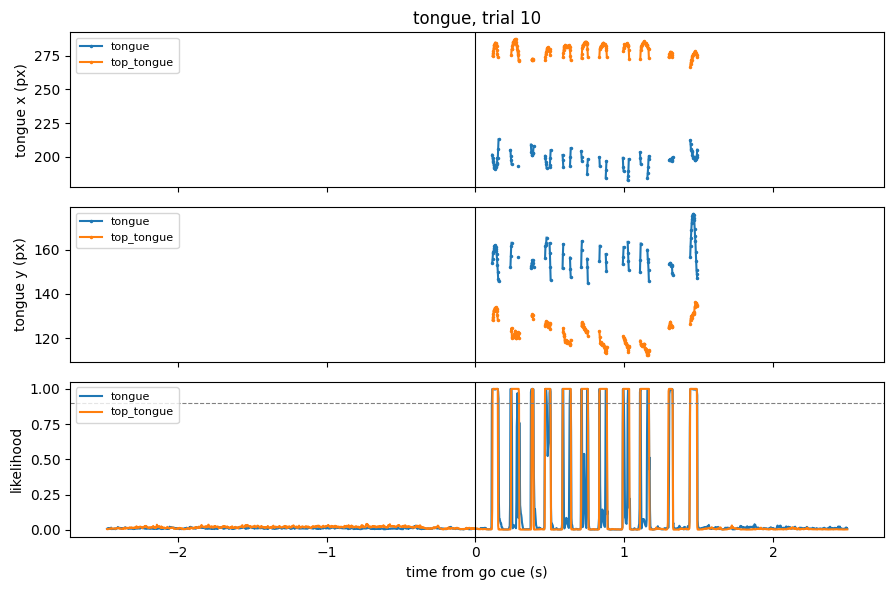

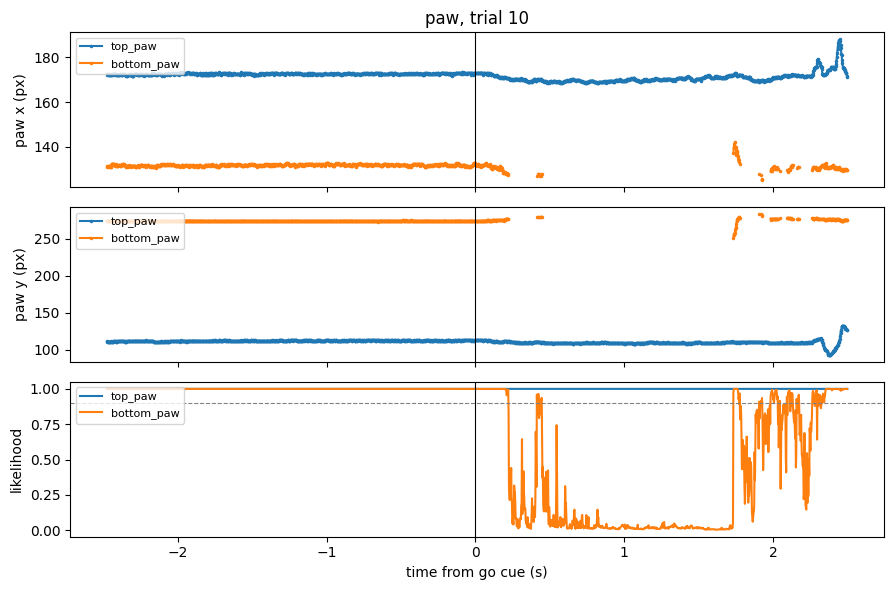

In [9]:
# Step 3: plot the tracking of the example trial over the decoding window
def plot_tracking(obj, trial, stream):
    """x, y, and likelihood of every feature making up a stream."""
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    for (feature, track), colour in zip(tracked_feature(obj, trial, stream).items(), ['C0', 'C1']):
        axes[0].plot(track.index, track.x, '.-', ms=3, color=colour, label=feature)
        axes[1].plot(track.index, track.y, '.-', ms=3, color=colour, label=feature)
        axes[2].plot(track.index, track.likelihood, color=colour, label=feature)

    for ax, label in zip(axes, [f'{stream} x (px)', f'{stream} y (px)', 'likelihood']):
        ax.set_ylabel(label)
        ax.axvline(0, color='k', lw=0.8)                   # go cue
        ax.legend(loc='upper left', fontsize=8)
    axes[2].axhline(0.9, color='gray', ls='--', lw=0.8)    # x and y are NaN below this
    axes[2].set_xlabel('time from go cue (s)')
    axes[0].set_title(f'{stream}, trial {trial}')
    fig.tight_layout()

plot_tracking(obj, trial, 'tongue')
plot_tracking(obj, trial, 'paw')

In [10]:
# Step 4: smooth the tracked position and differentiate it to get velocity.
# The tongue is only visible in short bouts, so smoothing and differentiating run over
# each contiguous run of valid frames separately, never across a gap. 'mirror' reflects
# about the end sample without repeating it, which distorts the short runs least.
LIKELIHOOD_CUT = 0.9
SMOOTH_SIGMA_MS = 5

def valid_runs(valid):
    """First and last+1 index of each contiguous run of valid frames."""
    edges = np.diff(np.concatenate([[0], valid.astype(int), [0]]))
    return zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1))

def velocity(track):
    """Smoothed position and combined velocity of a feature, over the valid frames only."""
    out = pd.DataFrame(np.nan, index=track.index, columns=['x', 'y', 'velocity'])
    if len(track) < 2:                       # a few trials have no frame times at all
        return out

    time = track.index.to_numpy()
    sigma = SMOOTH_SIGMA_MS / 1000 / np.median(np.diff(time))       # kernel width in frames
    valid = track.likelihood.to_numpy() > LIKELIHOOD_CUT            # x and y are NaN below this

    for start, stop in valid_runs(valid):
        rows = out.index[start:stop]
        x = gaussian_filter1d(track.x.to_numpy()[start:stop], sigma, mode='mirror')
        y = gaussian_filter1d(track.y.to_numpy()[start:stop], sigma, mode='mirror')
        out.loc[rows, 'x'] = x
        out.loc[rows, 'y'] = y
        if stop - start > 1:                                        # a lone frame has no velocity
            out.loc[rows, 'velocity'] = np.hypot(np.gradient(x, time[start:stop]),
                                                 np.gradient(y, time[start:stop]))
    return out

for stream in FEATURES:
    for feature, track in tracked_feature(obj, trial, stream).items():
        vel = velocity(track)
        runs = sum(1 for _ in valid_runs(track.likelihood.to_numpy() > LIKELIHOOD_CUT))
        print(f'{stream:6s} {feature:11s} {vel.x.notna().sum():4d} valid frames in {runs:2d} runs, '
              f'velocity {vel.velocity.min():5.1f} to {vel.velocity.max():7.1f} px/s, '
              f'median {vel.velocity.median():6.1f}')

tongue tongue       102 valid frames in 18 runs, velocity   0.0 to  1356.7 px/s, median  231.2
tongue top_tongue   189 valid frames in 11 runs, velocity  10.9 to   695.9 px/s, median  222.5
paw    top_paw     1990 valid frames in  1 runs, velocity   0.9 to  1227.8 px/s, median   24.6
paw    bottom_paw  1233 valid frames in 24 runs, velocity   0.0 to  1069.7 px/s, median   22.2


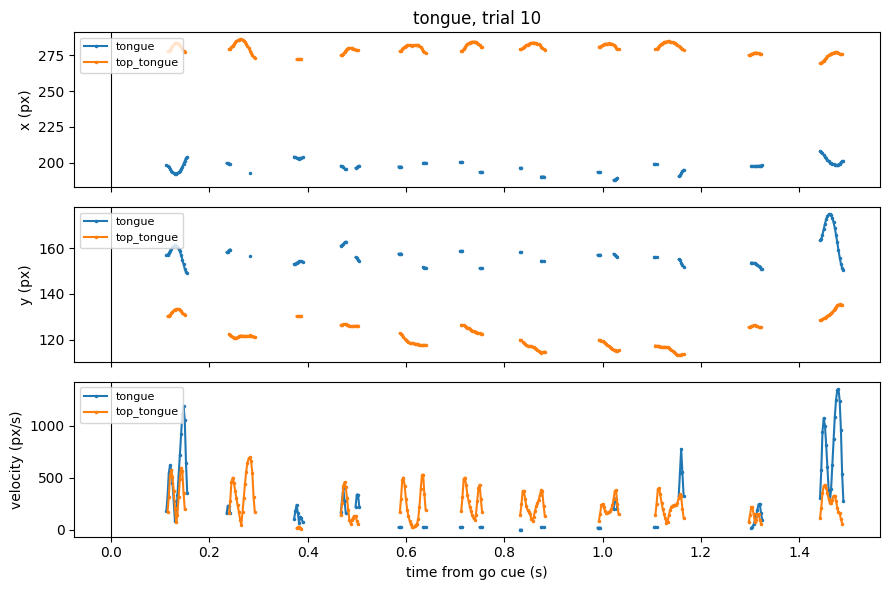

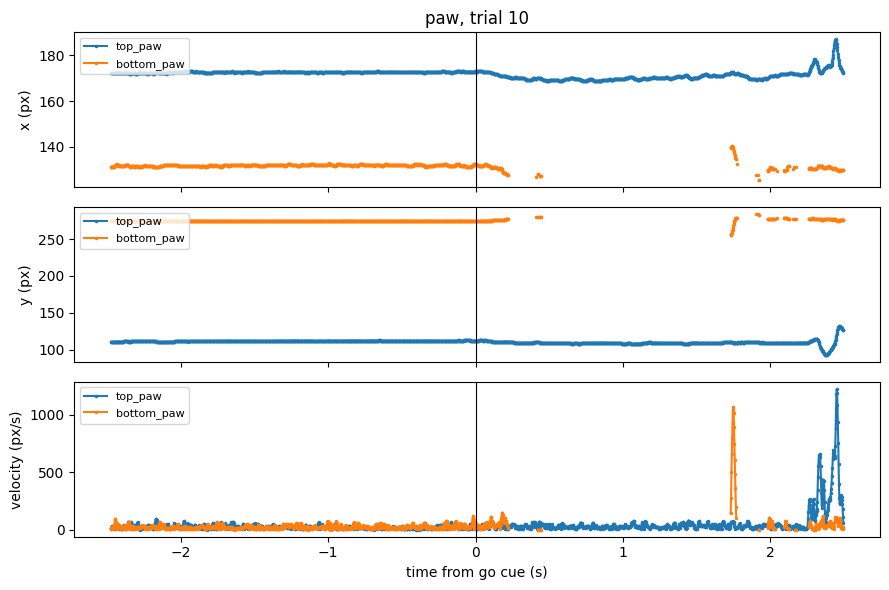

In [11]:
# Step 5: plot the smoothed position and velocity of the example trial
def plot_velocity(obj, trial, stream):
    """Smoothed position and velocity of every feature making up a stream."""
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    for (feature, track), colour in zip(tracked_feature(obj, trial, stream).items(), ['C0', 'C1']):
        vel = velocity(track)
        for ax, column in zip(axes, vel.columns):
            ax.plot(vel.index, vel[column], '.-', ms=3, color=colour, label=feature)

    for ax, label in zip(axes, ['x (px)', 'y (px)', 'velocity (px/s)']):
        ax.set_ylabel(label)
        ax.axvline(0, color='k', lw=0.8)          # go cue
        ax.legend(loc='upper left', fontsize=8)
    axes[2].set_xlabel('time from go cue (s)')
    axes[0].set_title(f'{stream}, trial {trial}')
    fig.tight_layout()

plot_velocity(obj, trial, 'tongue')
plot_velocity(obj, trial, 'paw')

In [12]:
# Step 6: the 5 ms grid, matching params.dt = 1/200 in the reference code
BIN = 0.005
BIN_EDGES = T_START + BIN * np.arange(round((T_STOP - T_START) / BIN) + 1)
TIME = BIN_EDGES[:-1] + BIN / 2           # bin centres, the decoder input

TONGUE_VIEWS = ['tongue', 'top_tongue']   # side and bottom camera
PAW_FEATURE = 'top_paw'                   # the other paw drops out during the delay
NORMALIZE_PCT = 90                        # puts the two tongue views on a common scale
SPLIT_PCT = 50                            # splits the two velocity classes

MOVEMENT = {'below threshold': 0, 'above threshold': 1, 'not visible': 2}

def bin_frames(time, values):
    """Mean of the valid frames in each bin, NaN where a bin holds no valid frame."""
    bin_of_frame = np.searchsorted(BIN_EDGES, time, side='right') - 1
    valid = np.isfinite(values) & (bin_of_frame >= 0) & (bin_of_frame < TIME.size)
    total = np.bincount(bin_of_frame[valid], weights=values[valid], minlength=TIME.size)
    count = np.bincount(bin_of_frame[valid], minlength=TIME.size)
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)

def mean_over_available(rows):
    """Mean down the rows, NaN only where every row is NaN."""
    rows = np.vstack(rows)
    count = np.sum(np.isfinite(rows), axis=0)
    total = np.nansum(rows, axis=0)
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)

def discretize(values, threshold):
    """Two velocity classes split at the threshold, plus a class for untracked bins."""
    code = np.where(values >= threshold, MOVEMENT['above threshold'], MOVEMENT['below threshold'])
    return np.where(np.isnan(values), MOVEMENT['not visible'], code)

print(f'{TIME.size} bins of {BIN * 1000:.0f} ms over [{BIN_EDGES[0]}, {BIN_EDGES[-1]}] s, '
      f'centres {TIME[0]:.4f} to {TIME[-1]:.4f} s')

1000 bins of 5 ms over [-2.5, 2.5] s, centres -2.4975 to 2.4975 s


In [ ]:
# Step 7: from per-feature velocity to the one velocity each stream contributes.
# The two tongue views sit on different pixel scales, so each is divided by its own
# session-wide percentile before they are averaged.
def frame_velocity(obj, trials, feature):
    """Velocity of one feature at camera resolution, one entry per trial."""
    return {trial: velocity(tracking(obj, trial, feature)).velocity for trial in trials}

def session_percentile(traces, percentile):
    """Percentile of a velocity pooled over every frame and trial of the session."""
    return np.nanpercentile(np.concatenate([trace.to_numpy() for trace in traces.values()]), percentile)

def tongue_velocity(traces, scale, trial):
    """The two tongue views, each divided by its own scale, averaged where both are tracked."""
    return mean_over_available([traces[view][trial].to_numpy() / scale[view] for view in TONGUE_VIEWS])

tongue_traces = {view: frame_velocity(obj, info.index, view) for view in TONGUE_VIEWS}
tongue_scale = {view: session_percentile(tongue_traces[view], NORMALIZE_PCT) for view in TONGUE_VIEWS}
print('tongue view scales (%dth pct of velocity, px/s): ' % NORMALIZE_PCT
      + ', '.join(f'{view} {value:.1f}' for view, value in tongue_scale.items()))

combined = tongue_velocity(tongue_traces, tongue_scale, trial)
print(f'trial {trial}: combined tongue velocity available in {np.isfinite(combined).sum()} of '
      f'{combined.size} frames, range {np.nanmin(combined):.2f} to {np.nanmax(combined):.2f}')

In [18]:
# Step 8: show a session as an image, one row per trial
def plot_session(binned, codes, thresholds, title=''):
    """Each continuous stream above the classes it was cut into."""
    streams = list(binned)
    fig, axes = plt.subplots(2, len(streams), figsize=(5 * len(streams), 7), sharex=True, sharey=True)
    extent = [T_START, T_STOP, len(next(iter(binned.values()))), 0]

    for column, stream in enumerate(streams):
        top = axes[0, column].imshow(binned[stream], aspect='auto', extent=extent,
                                     interpolation='nearest', cmap='viridis',
                                     vmax=np.nanpercentile(binned[stream], 99))
        axes[0, column].set_title(f'{stream} (threshold {thresholds[stream]:.2f})')
        fig.colorbar(top, ax=axes[0, column])

        bottom = axes[1, column].imshow(codes[stream], aspect='auto', extent=extent,
                                        interpolation='nearest', cmap='viridis', vmin=0, vmax=2)
        axes[1, column].set_title(f'{stream} class')
        bar = fig.colorbar(bottom, ax=axes[1, column], ticks=list(MOVEMENT.values()))
        bar.ax.set_yticklabels(list(MOVEMENT))

    for ax in axes.ravel():
        ax.axvline(0, color='w', lw=0.8)          # go cue
    for ax in axes[:, 0]:
        ax.set_ylabel('trial')
    for ax in axes[1]:
        ax.set_xlabel('time from go cue (s)')
    fig.suptitle(title)
    fig.tight_layout()

### Motion Engery 

In [ ]:
# Motion energy sits in its own file next to the data structure, one value per camera
# frame. Most files hold {data, moveThresh}, a few hold just the per-trial cell array,
# and three wrap {data, moveThresh} twice, so unwrap until the per-trial array appears.
def motion_energy(name):
    """Motion energy of each trial of a session, on the same frames as the tracking."""
    for folder in EPHYS:
        path = DATA / folder / f'motionEnergy_{name}.mat'
        if path.exists():
            me = scipy.io.loadmat(path, simplify_cells=True)['me']
            while isinstance(me, dict):
                me = me['data']
            return me
    raise FileNotFoundError(name)

session = 'JEB19_2023-04-19'
energy = motion_energy(session)
print(f'{len(energy)} trials, one trace per trial')

for t in [0, 3, 10, 222]:
    trace, frames = energy[t], camera_time(obj, t)
    print(f'  trial {t:3d}: {trace.size} values vs {frames.size} camera frames, '
          f'range {np.nanmin(trace):.2f} to {np.nanmax(trace):.2f}, NaNs {np.isnan(trace).sum()}')

lengths_match = all(energy[t].size == camera_time(obj, t).size
                    for t in range(int(np.ravel(bp['Ntrials'])[0])))
print('one motion energy value per camera frame on every trial:', lengths_match)

## Behavioral Variables

In [16]:
# Everything a session contributes to the decoder outputs.
#   per trial   : outcome, context, lick direction
#   per 5 ms bin: tongue velocity, paw velocity, motion energy, each cut in two at the
#                 session median, with a third class where the camera has nothing to say
def energy_trace(obj, trial, energy):
    """Motion energy of one trial over the frames inside the window, with their frame times."""
    time = camera_time(obj, trial)
    inside = (time >= T_START) & (time <= T_STOP)
    return time[inside], energy[trial][inside]

def camera_velocity(obj, session, trials):
    """Binned tongue velocity, paw velocity, and motion energy, as (n_trials, n_bins) arrays."""
    traces = {feature: frame_velocity(obj, trials, feature)
              for feature in TONGUE_VIEWS + [PAW_FEATURE]}
    scale = {view: session_percentile(traces[view], NORMALIZE_PCT) for view in TONGUE_VIEWS}
    energy = motion_energy(session)

    binned = {stream: [] for stream in ['tongue_velocity', 'paw_velocity', 'motion_energy']}
    for trial in trials:
        time = traces[PAW_FEATURE][trial].index.to_numpy()      # shared by every tracked feature
        binned['tongue_velocity'].append(bin_frames(time, tongue_velocity(traces, scale, trial)))
        binned['paw_velocity'].append(bin_frames(time, traces[PAW_FEATURE][trial].to_numpy()))
        binned['motion_energy'].append(bin_frames(*energy_trace(obj, trial, energy)))
    return {stream: np.array(rows) for stream, rows in binned.items()}, scale

def camera_outputs(obj, session, trials):
    """The camera streams cut into classes, each at its own session threshold."""
    binned, scale = camera_velocity(obj, session, trials)
    thresholds = {stream: np.nanpercentile(values, SPLIT_PCT) for stream, values in binned.items()}
    codes = {stream: discretize(values, thresholds[stream]) for stream, values in binned.items()}
    return binned, codes, thresholds, scale

def session_outputs(session):
    """Per-trial and per-bin decoder outputs of one session."""
    obj = load_mat(sessions[session])
    info = trial_info(obj['bp'])
    binned, codes, thresholds, scale = camera_outputs(obj, session, info.index)
    return dict(trials=info, binned=binned, codes=codes, thresholds=thresholds, scale=scale)

session = 'JEB19_2023-04-19'
out = session_outputs(session)

print(f'{session}: {len(out["trials"])} trials kept, {TIME.size} bins of {BIN * 1000:.0f} ms\n')
for column, values in zip(out['trials'], [OUTCOME, CONTEXT, LICK]):
    counts = out['trials'][column].value_counts()
    print(f'{column:15s} ' + '  '.join(f'{label} {counts.get(code, 0)}' for label, code in values.items()))

print()

for stream, values in out['binned'].items():
    fractions = {label: (out['codes'][stream] == code).mean() for label, code in MOVEMENT.items()}
    print(f'{stream:16s} threshold {out["thresholds"][stream]:6.2f}   '
          + '  '.join(f'{label} {fraction:.3f}' for label, fraction in fractions.items()))

JEB19_2023-04-19: 216 trials kept, 1000 bins of 5 ms

outcome         incorrect 24  correct 122  ignore 70
context         WC 84  DR 132
lick_direction  left 76  right 70  no lick 70

tongue_velocity  threshold   0.40   below threshold 0.032  above threshold 0.032  not visible 0.936
paw_velocity     threshold  21.45   below threshold 0.491  above threshold 0.491  not visible 0.019
motion_energy    threshold   8.00   below threshold 0.493  above threshold 0.498  not visible 0.010


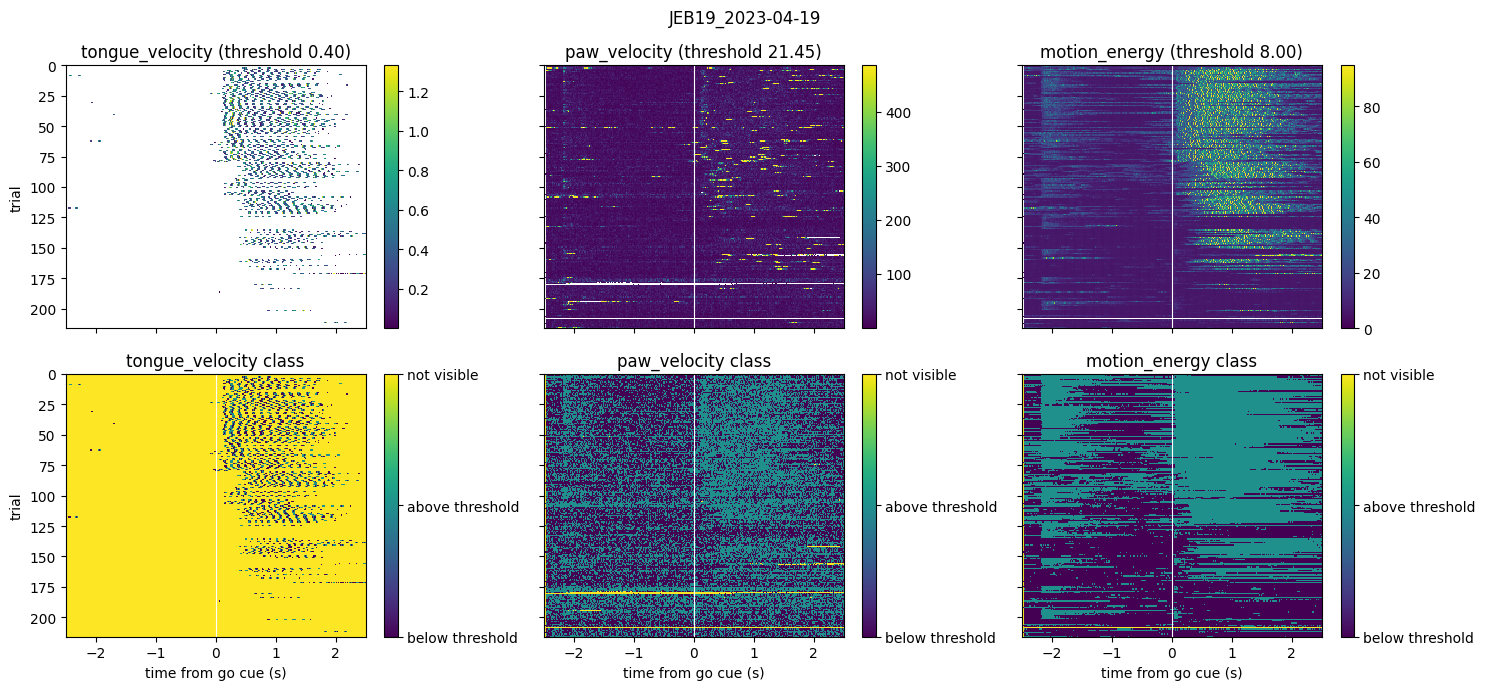

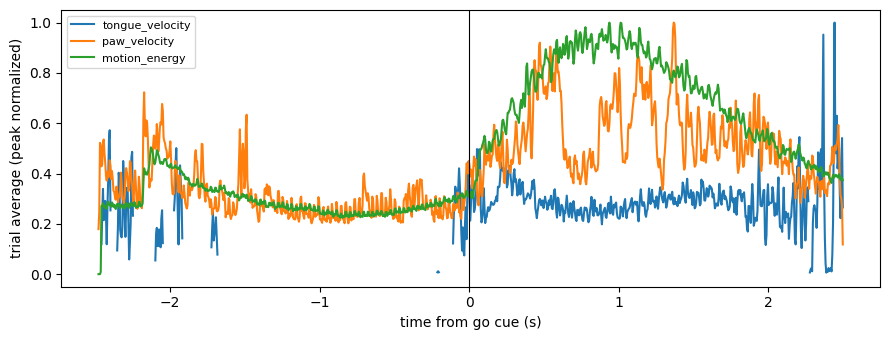

In [19]:
# the three continuous streams and the classes they were cut into, one row per trial
plot_session(out['binned'], out['codes'], out['thresholds'], title=session)

# and their session-wide time course, to check the go cue lines up with the behavior
fig, ax = plt.subplots(figsize=(9, 3.5))
for stream, values in out['binned'].items():
    average = mean_over_available(values)
    ax.plot(TIME, average / np.nanmax(average), label=stream)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('time from go cue (s)')
ax.set_ylabel('trial average (peak normalized)')
ax.legend(fontsize=8)
fig.tight_layout()

## Neural Data

In [21]:
# Spike times are already on the behavior clock and relative to trial start, so aligning
# to the go cue is one subtraction. Quality is a free text label, written with either
# case and with a few typos, so it is matched in lower case.
QUALITY_DROP = {'garbage', 'gabrga', 'noisy', 'real?', 'poor'}
MIN_RATE = 1.0          # Hz, mean over the window, as in the paper
RATE_SD_MS = 14         # matches gausswin(15) in the reference, whose sigma is 14/(2*2.5)
                        # = 2.8 bins, but applied to both sides rather than causally

def probe_clusters(obj, probe):
    """One dict per cluster on the given probe, however the file stores them."""
    entry = obj['clu'][probe - 1]
    if isinstance(entry, dict) and isinstance(entry['tm'], list):
        # one entry per probe, each field holding one array per cluster
        return [{field: entry[field][i] for field in entry} for i in range(len(entry['tm']))]
    return obj['clu']                            # one entry per cluster, single probe files

def unit_quality(cluster):
    """Quality label of a cluster; a handful carry no label at all."""
    label = cluster['quality']
    return label.strip().lower() if isinstance(label, str) else ''

def spike_counts(cluster, go_cue, trials):
    """Spikes of one cluster per trial and bin, aligned to the go cue."""
    trial_of_spike = np.asarray(cluster['trial'], int) - 1     # trial numbers are 1 based
    aligned = np.asarray(cluster['trialtm'], float) - go_cue[trial_of_spike]

    row_of_trial = np.full(go_cue.size, -1)
    row_of_trial[trials] = np.arange(len(trials))
    row = row_of_trial[trial_of_spike]
    column = np.searchsorted(BIN_EDGES, aligned, side='right') - 1

    inside = (row >= 0) & (column >= 0) & (column < TIME.size)
    flat = np.bincount(row[inside] * TIME.size + column[inside], minlength=len(trials) * TIME.size)
    return flat.reshape(len(trials), TIME.size)

def neural_rates(obj, probes, trials):
    """Smoothed firing rate of every unit that passes QC, as (n_units, n_trials, n_bins).

    'reflect' mirrors the real counts at the window edges. 'nearest' would hold a single
    busy edge bin for the whole half kernel and doubled the peak rate.
    """
    go_cue = trial_column(obj['bp'], 'ev', 'goCue')
    sigma = RATE_SD_MS / 1000 / BIN                            # kernel width in bins
    rates = []
    for probe in probes:
        for cluster in probe_clusters(obj, probe):
            if unit_quality(cluster) in QUALITY_DROP:
                continue
            rate = spike_counts(cluster, go_cue, trials) / BIN
            if rate.mean() <= MIN_RATE:
                continue
            rates.append(gaussian_filter1d(rate, sigma, axis=1, mode='reflect'))
    return np.asarray(rates, np.float32)

session = 'JEB19_2023-04-19'
obj = load_mat(sessions[session])
info = trial_info(obj['bp'])
rates = neural_rates(obj, SESSIONS[session], info.index)

on_file = sum(len(probe_clusters(obj, probe)) for probe in SESSIONS[session])
print(f'{session}: probes {SESSIONS[session]}, {on_file} clusters on file -> {rates.shape[0]} units after QC')
print(f'neural: {rates.shape} (units, trials, bins)')
print(f'firing rate {rates.min():.2f} to {rates.max():.2f} Hz, mean {rates.mean():.2f} Hz')

JEB19_2023-04-19: probes [1], 567 clusters on file -> 33 units after QC
neural: (33, 216, 1000) (units, trials, bins)
firing rate 0.00 to 360.28 Hz, mean 6.50 Hz


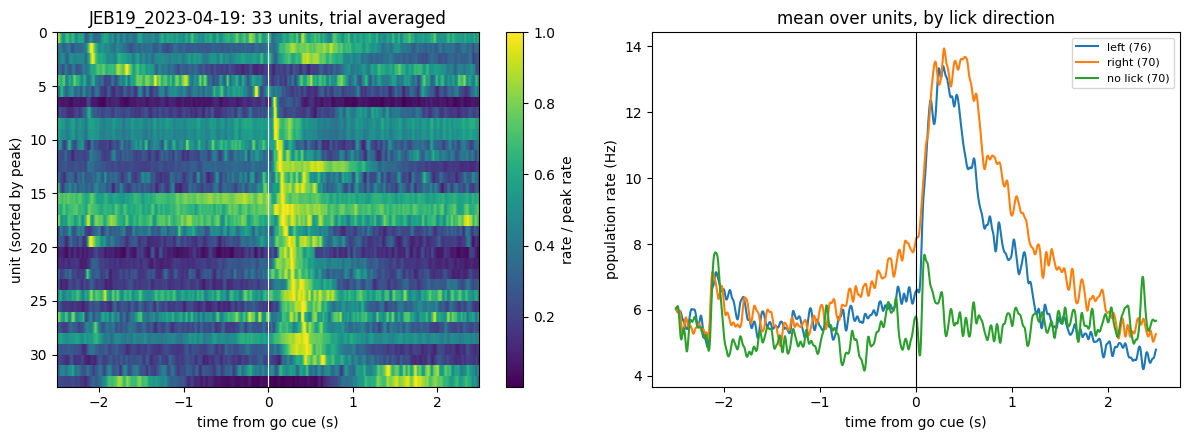

In [22]:
# every unit as a row, and the population split by what the animal did
psth = rates.mean(axis=1)                                 # (units, bins), averaged over trials
order = np.argsort(np.argmax(psth, axis=1))               # sort by when each unit peaks
normalized = psth[order] / psth[order].max(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image = axes[0].imshow(normalized, aspect='auto', extent=[T_START, T_STOP, len(psth), 0],
                       interpolation='nearest', cmap='viridis')
axes[0].set(xlabel='time from go cue (s)', ylabel='unit (sorted by peak)',
            title=f'{session}: {len(psth)} units, trial averaged')
fig.colorbar(image, ax=axes[0], label='rate / peak rate')

for label, code in LICK.items():
    chosen = out['trials'].lick_direction.to_numpy() == code
    if chosen.any():
        axes[1].plot(TIME, rates[:, chosen].mean(axis=(0, 1)), label=f'{label} ({chosen.sum()})')
axes[1].set(xlabel='time from go cue (s)', ylabel='population rate (Hz)',
            title='mean over units, by lick direction')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.axvline(0, color='w' if ax is axes[0] else 'k', lw=0.8)
fig.tight_layout()